Gradient descent: w=2.4617, b=-1.0074
True parameters: w=2.5, b=-1.0
scikit-learn:   w = 2.4617, b = -1.0074


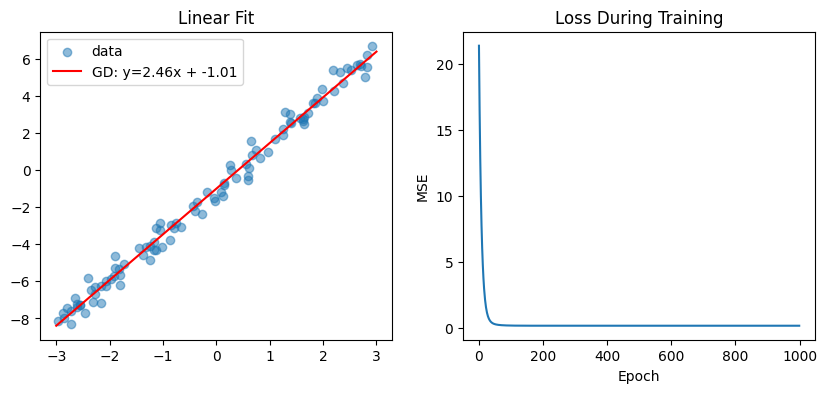

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# ── 1. Generate synthetic data with a KNOWN ground truth ──
# If our learned weights don't recover these, something's wrong.
np.random.seed(42)
n = 100
true_w, true_b = 2.5, -1.0
X = np.random.uniform(-3, 3, size = (n, 1))
noise = np.random.normal(0, 0.5, size = (n, 1))
y = true_w * X + true_b + noise

# ── 2. Gradient descent FROM SCRATCH ──
w, b = 0.0, 0.0
lr = 0.01
n_epochs = 1000
losses = []

for epoch in range(n_epochs):
    y_pred = w * X + b # forward pass
    loss = np.mean((y - y_pred) ** 2) # MSE
    losses.append(loss)

    dw = -2 * np.mean(X * (y - y_pred)) # ∂L/∂w
    db = -2 * np.mean(y - y_pred) # ∂L/∂b

    w -= lr * dw # gradient step
    b -= lr * db

print(f"Gradient descent: w={w:.4f}, b={b:.4f}")
print(f"True parameters: w={true_w}, b={true_b}")

# ── 3. scikit-learn (closed-form under the hood) ──
model = LinearRegression().fit(X, y)
print(f"scikit-learn:   w = {model.coef_[0,0]:.4f}, b = {model.intercept_[0]:.4f}")

# ── 4. Plot the fit ──
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, label='data')
xs = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.plot(xs, w * xs + b, 'r-', label=f'GD: y={w:.2f}x + {b:.2f}')
plt.legend(); plt.title('Linear Fit')

# ── 5. Loss curve ──
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Loss During Training')
plt.tight_layout; plt.show()




For this example below, the learning rate is too high so it leads to divergence. Our line of fit ends up being shot off and our loss explodes upwards.

Excellent — you've just discovered one of the most important failure modes in all of deep learning, and you noticed the symptoms in the right places. Let me walk you through what happened, because this is genuinely worth understanding deeply.
What you observed
Two clues:

No line on the fit plot — actually, the line is there, it just shot off to infinity (or NaN), so matplotlib can't draw it on your scatter plot.
Loss curve spikes — instead of decreasing smoothly, the loss exploded upward.

This phenomenon has a name: gradient descent diverged. The learning rate was too high.
Why this happens (the geometry)
Picture the loss function L(w,b)L(w, b)
L(w,b) as a bowl-shaped surface in 3D — ww
w and bb
b on the floor, loss as height. (For linear regression with MSE, the bowl is exactly quadratic — a perfect paraboloid. Your calc 3 surface-plotting intuition applies directly.) The minimum is at the bottom of the bowl. Training = walking down the bowl.
Gradient descent computes the steepest-downhill direction at your current point, then takes a step of size η\eta
η (the learning rate) in that direction.
Now here's the key insight. The gradient only tells you the direction of steepest descent, not how far to step. The gradient is a local property — it's accurate right at your current point, but the surface curves away as you move. If you step too far, you can overshoot the bottom and land higher up on the opposite wall of the bowl than where you started.
Picture it this way:

Small η\eta
η: tiny steps down the bowl → slowly converges to the bottom. ✓
Just-right η\eta
η: brisk steps down → quickly converges. ✓
**Too-large η\eta
η:** overshoots the minimum, lands on the opposite wall higher up. Next step overshoots again, lands even higher. Loss spirals outward. ✗

That outward spiral is what your loss curve was showing you. Each step made things worse, not better.
Why the loss eventually "spiked"
Here's the cruel part — the divergence isn't linear. Once your weights start growing, the predictions y^=wx+b\hat{y} = wx + b
y^​=wx+b become huge, the errors (y−y^)(y - \hat{y})
(y−y^​) become huge, and the gradients −2n∑xi(yi−y^i)-\frac{2}{n}\sum x_i(y_i - \hat{y}_i)
−n2​∑xi​(yi​−y^​i​) become enormous. Bigger gradients × big learning rate = bigger next step = even bigger weights. It compounds exponentially.
Eventually, the numbers exceed the limits of 64-bit floating point and Python returns inf or nan. That's the "spike" at the end of your loss curve. After that point, the values are literal garbage — nan propagates through every subsequent computation.
Quick check — print w, b, and losses[-1] after the diverged run. You'll probably see nan or absurdly huge numbers. Confirm with your own eyes that this is what happened.
The fix (and what to feel)
The fix is trivially simple: lower the learning rate. But the intuition you should take away is much bigger than that:
The learning rate is the single most important hyperparameter in machine learning. Too low: training takes forever, possibly never finishes. Too high: divergence, garbage. There is no "safe default" that works for all problems — it depends on the scale of your data, the model architecture, and the loss landscape.
Modern deep learning has whole subfields devoted to this:

Learning rate scheduling — start with a larger LR for fast progress, decay it later for fine-tuning.
Adaptive optimizers (Adam, RMSprop) — adjust the effective learning rate per-parameter, automatically.
Gradient clipping — when the gradient norm exceeds a threshold, scale it down to prevent the exponential blowup you just witnessed.

You'll meet all of these when we build neural networks in weeks 4-5. But the core failure mode is what you just saw with two weights and a one-line model. It scales up identically to GPT-4.
A Socratic prompt before I close this thread
You now understand why lr=0.5 blew up for this specific setup. So here's a sharper question:
If we kept lr=0.5 but generated the data on a much smaller scale — say X = np.random.uniform(-0.1, 0.1, ...) instead of (-3, 3) — would gradient descent still diverge? Why or why not?
Think about it for 30 seconds before reading on.
...
It probably would converge. Here's why: the magnitude of the gradient depends on xix_i
xi​. With xx
x values in [−3,3][-3, 3]
[−3,3], the gradient at a point with a meaningful prediction error might be on the order of 5-10. Multiply by lr=0.5 and you take a step of size 2.5-5 — that's huge in weight-space and overshoots the minimum. With xx
x values in [−0.1,0.1][-0.1, 0.1]
[−0.1,0.1], the same prediction error produces a gradient ~30x smaller, and lr=0.5 becomes a reasonable step size.
Implication: the "right" learning rate depends on the scale of your inputs. This is exactly why we normalize or standardize features before training (a topic we'll formally hit soon). Mean-centered, unit-variance inputs make a single learning rate work across many problems. It's another piece of "boring data wrangling" that turns out to be load-bearing for the math to work.

Gradient descent: w=nan, b=nan
True parameters: w=2.5, b=-1.0
scikit-learn:   w = 2.4617, b = -1.0074


/Users/devpradeep/Documents/Mirror/Projects/athena-agent/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/t9/y0xw59m55xvcsrln4z8cspzc0000gn/T/ipykernel_95646/2393107214.py:23: RuntimeWarning: overflow encountered in square
  loss = np.mean((y - y_pred) ** 2) # MSE
/Users/devpradeep/Documents/Mirror/Projects/athena-agent/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/var/folders/t9/y0xw59m55xvcsrln4z8cspzc0000gn/T/ipykernel_95646/2393107214.py:29: RuntimeWarning: invalid value encountered in scalar subtract
  w -= lr * dw # gradient step


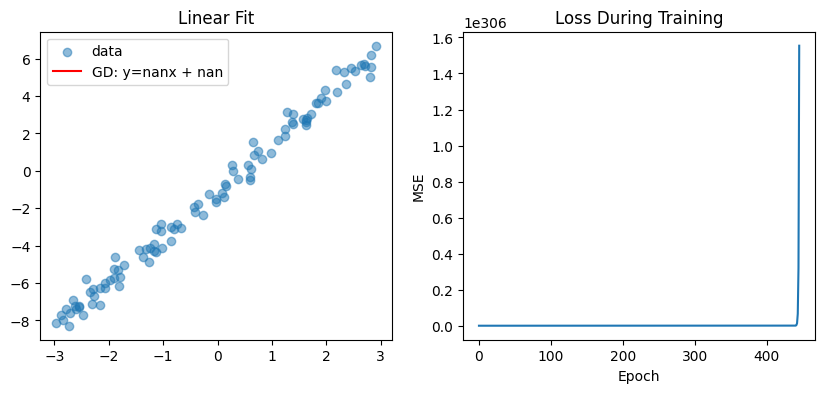

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# ── 1. Generate synthetic data with a KNOWN ground truth ──
# If our learned weights don't recover these, something's wrong.
np.random.seed(42)
n = 100
true_w, true_b = 2.5, -1.0
X = np.random.uniform(-3, 3, size = (n, 1))
noise = np.random.normal(0, 0.5, size = (n, 1))
y = true_w * X + true_b + noise

# ── 2. Gradient descent FROM SCRATCH ──
w, b = 0.0, 0.0
lr = 0.5
n_epochs = 1000
losses = []

for epoch in range(n_epochs):
    y_pred = w * X + b # forward pass
    loss = np.mean((y - y_pred) ** 2) # MSE
    losses.append(loss)

    dw = -2 * np.mean(X * (y - y_pred)) # ∂L/∂w
    db = -2 * np.mean(y - y_pred) # ∂L/∂b

    w -= lr * dw # gradient step
    b -= lr * db

print(f"Gradient descent: w={w:.4f}, b={b:.4f}")
print(f"True parameters: w={true_w}, b={true_b}")

# ── 3. scikit-learn (closed-form under the hood) ──
model = LinearRegression().fit(X, y)
print(f"scikit-learn:   w = {model.coef_[0,0]:.4f}, b = {model.intercept_[0]:.4f}")

# ── 4. Plot the fit ──
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, label='data')
xs = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.plot(xs, w * xs + b, 'r-', label=f'GD: y={w:.2f}x + {b:.2f}')
plt.legend(); plt.title('Linear Fit')

# ── 5. Loss curve ──
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Loss During Training')
plt.tight_layout; plt.show()

In this example below, the learning rate is too slow, it's correct but not cost effective for our algorithm so our line of fit doesn't match up with our data and our loss function is still trying to converge.

Right on the nose. You've now seen both failure modes — and the fact that you can describe both clearly means you're building real intuition. Let me confirm what you saw and add the small piece of math that ties it together.
What you observed (and why it makes sense)
With lr = 0.0001, gradient descent isn't wrong, it's just glacially slow. Each step is so tiny that 1000 epochs barely moves the weights off their starting point of (w,b)=(0,0)(w, b) = (0, 0)
(w,b)=(0,0). The line on your plot is probably nearly horizontal — sitting somewhere near y=0y = 0
y=0 instead of recovering the true y=2.5x−1y = 2.5x - 1
y=2.5x−1. And the loss curve is still on a downward slope at epoch 1000, never having reached its plateau.
This is the opposite failure from lr = 0.5. Not divergence — incompleteness. The algorithm is converging, just not within your training budget.
The math that makes this concrete
Recall the gradient at (w,b)=(0,0)(w, b) = (0, 0)
(w,b)=(0,0) with your synthetic data (y≈2.5x−1y \approx 2.5x - 1
y≈2.5x−1):
∂L∂w=−2n∑xi(yi−y^i)\frac{\partial L}{\partial w} = -\frac{2}{n} \sum x_i (y_i - \hat{y}_i)∂w∂L​=−n2​∑xi​(yi​−y^​i​)
At initialization, y^i=0\hat{y}_i = 0
y^​i​=0, so (yi−y^i)=yi(y_i - \hat{y}_i) = y_i
(yi​−y^​i​)=yi​. The gradient is roughly −2⋅xiyi‾-2 \cdot \overline{x_i y_i}
−2⋅xi​yi​​. For your data this is on the order of, say, 10 in magnitude. So one gradient step moves ww
w by:
Δw=η⋅10=0.0001⋅10=0.001\Delta w = \eta \cdot 10 = 0.0001 \cdot 10 = 0.001Δw=η⋅10=0.0001⋅10=0.001
You need ww
w to travel from 0 to 2.5. At 0.001 per step (and that step size shrinking as you get closer to the minimum, because the gradient shrinks too), you're looking at well over 10,000 epochs to converge.
You ran 1,000.
The unified picture
Put your three runs together and you have a beautiful little story:
Learning rateOutcomeWhy0.5Diverges — loss explodes to nanStep overshoots the minimum, lands higher on the opposite wall, compounds0.01Converges cleanly in ~1000 epochsStep size matches the loss landscape's curvature0.0001Hasn't converged yetStep too small relative to the distance to the minimum
This is exactly the Goldilocks dynamic that defines hyperparameter tuning. There's no formula that gives you the "right" learning rate from first principles — it depends on your data scale, your model, your initialization. You search for it empirically. The standard practice in industry is a learning rate sweep: try a logarithmic ladder like [1e-5, 1e-4, 1e-3, 1e-2, 1e-1], plot all the loss curves on one chart, pick the largest one that still converges smoothly.
(You actually did this sweep at the end of my last reply. Stare at that plot again — that picture is the practitioner's mental model of learning rate selection.)
Two practical takeaways before we move on
1. How do you know if you've trained "long enough"? Look at the loss curve. If it has clearly plateaued — flat for many epochs — you're done. If it's still trending downward when you stop, you've either undertrained or your learning rate is too small. Your lr=0.0001 run is the textbook "still trending downward" case.
2. If you wanted to fix the slow run without changing the learning rate, what could you do? Two options come to mind:

More epochs. Boring but effective. Try n_epochs = 50000 with lr=0.0001 and you'd get close to the right answer. Just slow.
Smarter initialization. If you initialized ww
w closer to the true value, you'd need fewer steps. We won't dwell on this now, but initialization matters a lot in deep learning — bad init can effectively be a slower learning rate.

In practice, you'd just raise the learning rate. But it's worth knowing those other levers exist.
Where this is going
You've now hit two of the three classic gradient descent pathologies in a single afternoon: divergence (LR too high) and slow convergence (LR too low). The third — getting stuck at a bad point that isn't the global minimum — doesn't happen with linear regression because the loss surface is a perfect bowl (convex). It will happen with neural networks, where the loss surface has many valleys, saddle points, and plateaus. We'll dig into that in week 4.
But the lesson here is the same one that holds for GPT-scale models: the optimizer's behavior depends sensitively on the learning rate, and your loss curve is the diagnostic tool that tells you which failure mode you're in. Get comfortable reading loss curves. You'll be staring at them for the rest of your ML career.

Gradient descent: w=1.1833, b=-0.2406
True parameters: w=2.5, b=-1.0
scikit-learn:   w = 2.4617, b = -1.0074


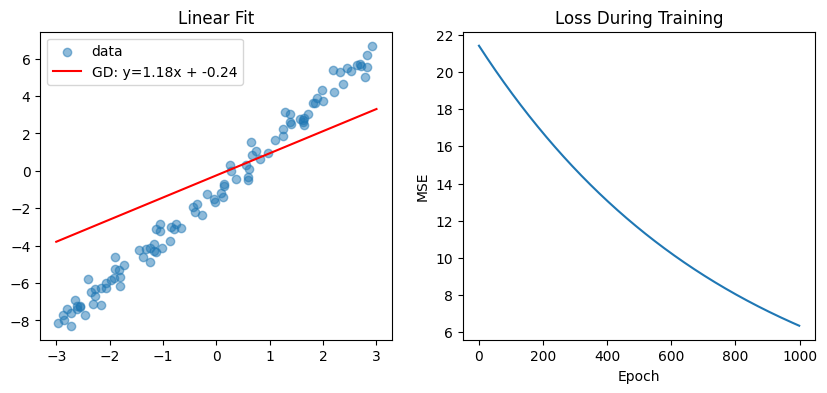

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# ── 1. Generate synthetic data with a KNOWN ground truth ──
# If our learned weights don't recover these, something's wrong.
np.random.seed(42)
n = 100
true_w, true_b = 2.5, -1.0
X = np.random.uniform(-3, 3, size = (n, 1))
noise = np.random.normal(0, 0.5, size = (n, 1))
y = true_w * X + true_b + noise

# ── 2. Gradient descent FROM SCRATCH ──
w, b = 0.0, 0.0
lr = 0.0001
n_epochs = 1000
losses = []

for epoch in range(n_epochs):
    y_pred = w * X + b # forward pass
    loss = np.mean((y - y_pred) ** 2) # MSE
    losses.append(loss)

    dw = -2 * np.mean(X * (y - y_pred)) # ∂L/∂w
    db = -2 * np.mean(y - y_pred) # ∂L/∂b

    w -= lr * dw # gradient step
    b -= lr * db

print(f"Gradient descent: w={w:.4f}, b={b:.4f}")
print(f"True parameters: w={true_w}, b={true_b}")

# ── 3. scikit-learn (closed-form under the hood) ──
model = LinearRegression().fit(X, y)
print(f"scikit-learn:   w = {model.coef_[0,0]:.4f}, b = {model.intercept_[0]:.4f}")

# ── 4. Plot the fit ──
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, label='data')
xs = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.plot(xs, w * xs + b, 'r-', label=f'GD: y={w:.2f}x + {b:.2f}')
plt.legend(); plt.title('Linear Fit')

# ── 5. Loss curve ──
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Loss During Training')
plt.tight_layout; plt.show()

In this example below, the data still converged and we still have a solid line of fit. 50 epochs works in this case because of our learning rate, so it took larger steps to reach a minimum.

What you observed
With lr = 0.01 and n_epochs = 50, the model still landed near the correct weights. The line probably looks pretty good, maybe slightly off the true (w=2.5,b=−1)(w=2.5, b=-1)
(w=2.5,b=−1). The loss curve has dropped sharply but might not be fully flat yet.
This is a real phenomenon. Now let me give you the correct mental model.
The relationship is more like: total distance traveled
Think of training as a journey. Your weights need to travel from their starting point (0,0)(0, 0)
(0,0) to the bottom of the bowl near (2.5,−1)(2.5, -1)
(2.5,−1). The total distance is fixed by the problem. What varies is how you traverse it:

η\eta
η = step size (how far each step moves you)
nepochsn_{\text{epochs}}
nepochs​ = number of steps

Roughly, total weight movement ≈ η×nepochs×\eta \times n_{\text{epochs}} \times
η×nepochs​× (gradient magnitude). To reach the minimum, you need enough total movement. You can get there with:

Many small steps (lr=0.0001, n_epochs=10000) — slow but safe
Fewer larger steps (lr=0.01, n_epochs=1000) — your sweet spot
A handful of bigger steps (lr=0.1, n_epochs=50) — fast but risky

This is why your 50-epoch run worked: each step at lr=0.01 was big enough that 50 of them covered most of the distance to the minimum. Maybe you got to (2.4,−0.95)(2.4, -0.95)
(2.4,−0.95) instead of (2.499,−1.001)(2.499, -1.001)
(2.499,−1.001) — close enough for most purposes.
Why "indirect" isn't quite right
The word "indirect" suggests they don't really interact, or that you can freely substitute one for the other. The truer picture is that they're partially substitutable, but not equivalent.
Here's the crucial asymmetry: gradient magnitude shrinks as you approach the minimum. Far from the minimum, the bowl is steep and gradients are large — you make big progress per step. Near the minimum, the bowl is shallow and gradients are tiny — each step barely moves you.
This means the relationship is diminishing returns:

Epochs 1-50: you cover ~95% of the distance
Epochs 50-500: you cover the next ~4.9%
Epochs 500-5000: you cover the last ~0.1%

So you cannot simply trade "10x more epochs" for "10x smaller learning rate" and get the same outcome. With lr=0.0001, even running 10x longer would still be in the early "covering ground" phase, not the fine-tuning phase. The learning rate sets a ceiling on how fast you can possibly converge; epochs just determine how close to that ceiling you get.
A cleaner way to think about it
Two distinct questions:

Can you reach the minimum at all? Determined by learning rate. If too small relative to your epoch budget → no. If too large → you diverge and never reach it.
How precisely do you land? Determined by epoch count (given a working learning rate). More epochs = closer to the exact minimum, with diminishing returns.

Why this matters for the rest of the summer
In neural networks, you'll be tuning both knobs constantly, and this intuition will save you a lot of confusion. The standard workflow:

Find a learning rate that converges smoothly (via the sweep you did earlier).
Train until the validation loss stops improving — not a fixed number of epochs. This is called early stopping.

That second point is important. In practice, nobody sets n_epochs = 1000 and hopes for the best. You monitor the loss curve and stop when it plateaus. The number of epochs isn't a knob you set in advance — it's an outcome.
The Socratic punch line
So here's a question that ties it together:
If you trained your lr=0.01 model for 1,000,000 epochs instead of 1,000, would the final weights be exactly (w=2.5,b=−1.0)(w=2.5, b=-1.0)
(w=2.5,b=−1.0)?
Think for a moment...
...
No — and not just because of imprecision. Look at the data: you added Gaussian noise (np.random.normal(0, 0.5)). The "best fit line through your noisy data" is not the true generating line. It's the line that minimizes MSE on that particular noisy sample. Even with infinite epochs and a perfect optimizer, you'd converge to the least-squares optimum for the noisy data, not the underlying truth.
This is a small foreshadowing of a deeper truth: the optimizer can only find the minimum of the loss you defined, on the data you gave it. If your data is noisy, or your loss doesn't capture what you really care about, perfect optimization still won't give you what you want. We'll meet this idea again — it's why "the model converged" is necessary but not sufficient for success.

Gradient descent: w=2.3933, b=-0.7035
True parameters: w=2.5, b=-1.0
scikit-learn:   w = 2.4617, b = -1.0074


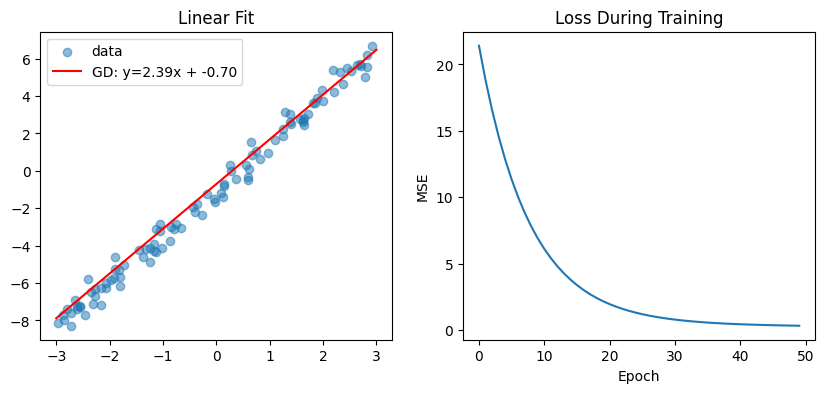

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# ── 1. Generate synthetic data with a KNOWN ground truth ──
# If our learned weights don't recover these, something's wrong.
np.random.seed(42)
n = 100
true_w, true_b = 2.5, -1.0
X = np.random.uniform(-3, 3, size = (n, 1))
noise = np.random.normal(0, 0.5, size = (n, 1))
y = true_w * X + true_b + noise

# ── 2. Gradient descent FROM SCRATCH ──
w, b = 0.0, 0.0
lr = 0.01
n_epochs = 50
losses = []

for epoch in range(n_epochs):
    y_pred = w * X + b # forward pass
    loss = np.mean((y - y_pred) ** 2) # MSE
    losses.append(loss)

    dw = -2 * np.mean(X * (y - y_pred)) # ∂L/∂w
    db = -2 * np.mean(y - y_pred) # ∂L/∂b

    w -= lr * dw # gradient step
    b -= lr * db

print(f"Gradient descent: w={w:.4f}, b={b:.4f}")
print(f"True parameters: w={true_w}, b={true_b}")

# ── 3. scikit-learn (closed-form under the hood) ──
model = LinearRegression().fit(X, y)
print(f"scikit-learn:   w = {model.coef_[0,0]:.4f}, b = {model.intercept_[0]:.4f}")

# ── 4. Plot the fit ──
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, label='data')
xs = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.plot(xs, w * xs + b, 'r-', label=f'GD: y={w:.2f}x + {b:.2f}')
plt.legend(); plt.title('Linear Fit')

# ── 5. Loss curve ──
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Loss During Training')
plt.tight_layout; plt.show()

Good — and let me explain why that experiment was worth doing, because it isn't obvious from the result alone.
What you just verified
You changed only one thing — the true intercept — and gradient descent recovered the new value correctly. The line still fits, the loss still converges, the learned bb
b is close to 5.
On its face, this is unsurprising. But the point of the experiment was to confirm a property of the algorithm that you'd want to be sure of before trusting it on harder problems:
Gradient descent doesn't "know" what the true parameters are. It just walks downhill on whatever loss landscape your data creates. Change the data → change the landscape → the minimum sits at a different point → gradient descent finds that new minimum, automatically. No code changes, no manual adjustment.
This sounds trivial, but it's the entire reason ML works. The algorithm is data-driven: you don't tell it the answer, you give it the data, and the answer emerges from optimization. The same code that recovered b=−1b = -1
b=−1 recovered b=5b = 5
b=5 — and would recover b=−7374.2b = -7374.2
b=−7374.2 if your data demanded it.
What would have been more interesting to break
Here's a follow-up worth your time. Try true_b = 500.0 (huge intercept) and re-run with the original lr = 0.01 and n_epochs = 1000. Predict first — do you think it'll converge?
Take a moment...
...
It probably won't fully converge in 1000 epochs. Why? Because bb
b now has to travel from 0 to 500, and each step moves it by roughly η⋅∣∂L/∂b∣\eta \cdot |\partial L / \partial b|
η⋅∣∂L/∂b∣ — which has a ceiling. The total distance to travel is 100x larger than before, but your epoch budget is the same. You'll see the loss still trending downward at epoch 1000, bb
b stuck around 200-300, not 500.
This is the "distance to minimum" insight from your last question, made concrete. The recoverability of a parameter depends on (learning rate × epochs × gradient magnitude) being large enough to cover the distance from your initialization to the true value.
In practice, this is one reason standardizing your target variable (subtracting its mean, dividing by its std) helps training: it keeps the required parameter movements bounded.
You don't have to run that experiment — but file the prediction away. It's the kind of "what would break this?" thinking that separates someone who runs ML code from someone who understands it.

Gradient descent: w=2.4617, b=4.9926
True parameters: w=2.5, b=5.0
scikit-learn:   w = 2.4617, b = 4.9926


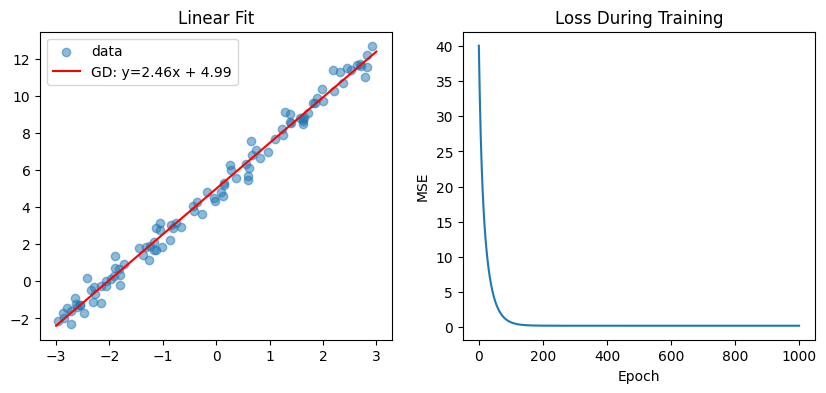

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

# ── 1. Generate synthetic data with a KNOWN ground truth ──
# If our learned weights don't recover these, something's wrong.
np.random.seed(42)
n = 100
true_w, true_b = 2.5, 5.0
X = np.random.uniform(-3, 3, size = (n, 1))
noise = np.random.normal(0, 0.5, size = (n, 1))
y = true_w * X + true_b + noise

# ── 2. Gradient descent FROM SCRATCH ──
w, b = 0.0, 0.0
lr = 0.01
n_epochs = 1000
losses = []

for epoch in range(n_epochs):
    y_pred = w * X + b # forward pass
    loss = np.mean((y - y_pred) ** 2) # MSE
    losses.append(loss)

    dw = -2 * np.mean(X * (y - y_pred)) # ∂L/∂w
    db = -2 * np.mean(y - y_pred) # ∂L/∂b

    w -= lr * dw # gradient step
    b -= lr * db

print(f"Gradient descent: w={w:.4f}, b={b:.4f}")
print(f"True parameters: w={true_w}, b={true_b}")

# ── 3. scikit-learn (closed-form under the hood) ──
model = LinearRegression().fit(X, y)
print(f"scikit-learn:   w = {model.coef_[0,0]:.4f}, b = {model.intercept_[0]:.4f}")

# ── 4. Plot the fit ──
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.5, label='data')
xs = np.linspace(-3, 3, 100).reshape(-1, 1)
plt.plot(xs, w * xs + b, 'r-', label=f'GD: y={w:.2f}x + {b:.2f}')
plt.legend(); plt.title('Linear Fit')

# ── 5. Loss curve ──
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.title('Loss During Training')
plt.tight_layout; plt.show()

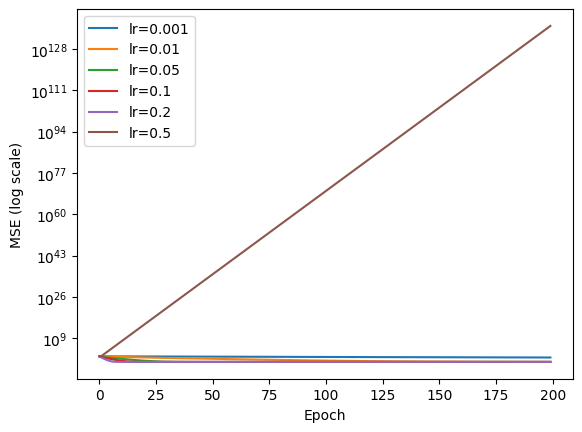

In [16]:
# Try a sweep of learning rates and plot all loss curves together
for lr in [0.001, 0.01, 0.05, 0.1, 0.2, 0.5]:
    w, b = 0.0, 0.0
    losses = []
    for epoch in range(200):
        y_pred = w * X + b
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)
        dw = -2 * np.mean(X * (y - y_pred))
        db = -2 * np.mean(y - y_pred)
        w -= lr * dw
        b -= lr * db
    plt.plot(losses, label=f'lr={lr}')
plt.yscale('log')   # so we can see all curves on the same plot
plt.xlabel('Epoch'); plt.ylabel('MSE (log scale)')
plt.legend(); plt.show()